#ML4Net - Lab 2

## Team members

Àlex Roger Moya (NIA 254095) | Pau Martínez Carrión (NIA 285580)

## Description

In this lab, you will implement an ML model that detects congestion in Wi-Fi networks. In particular, you will desing and implement a supervised learning model (e.g., linear regression, multi-layer perceptron, neural network), which you will train using a dataset that was generated using the ns-3 simulator.

Each row in the dataset is organized as (x1, x2, ..., x26, y1, y2, ..., y26, s, r, l), where:

* `x1, x2..., x26, y1, y2, ..., y26` represent the histogram of the Inter-Frame Space (IFS) values for M frames that accessed the medium in a 60 seconds observation sample.
  * `x26` represents the maximum IFS duration (in ms) in the considered M frames whereas `x1` is `x26`/26
  * The remaining `xi` values are buckets at uniform spacing between `x1` and `x26`.
  * For i>1, the values of `yi` represent the IFS histogram count (in percentage) for a corresponding bucket interval between `xi`-1 and `xi`.
  * In the case of `y1`, the bucket interval is between 0 and `x1`
* `s` is the average IFS duration (in ms)
* `r` is the percentage of frame collisions
* `l` is the label, where 1 indicates that the network is saturated, and 0, that it is not

Original dataset: https://ieee-dataport.org/documents/dataset-identification-saturated-and-unsaturated-wi-fi-networks

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 21 May 2026 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the dataset

In [2]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip

--2026-05-19 10:10:28--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip [following]
--2026-05-19 10:10:28--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1803279 (1.7M) [application/zip]
Saving to: ‘dataset_Lab2.zip’

dataset_Lab2.zip    100%[===================>]   1.72M  --.-KB/s    in 0.04s   

2026-05-19 10:10:29 (45.9 MB/

3. Define the main path of the code

In [3]:
mypath="drive/MyDrive/AAX/Lab2"

In [4]:
mypath="/content/drive/Shareddrives/AAX/Lab2"

4. Extract the source code to the destination folder

In [15]:
mkdir $mypath; cp dataset_Lab2.zip $mypath; cd $mypath; unzip dataset_Lab2.zip

y
mkdir: cannot create directory ‘/content/drive/Shareddrives/AAX/Lab2’: File exists
Archive:  dataset_Lab2.zip
replace test_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: test_data.csv           
replace __MACOSX/._test_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Visualizing the data




       0       1       2       3       4       5       6       7       8   \
0  0.0065  0.0130  0.0195  0.0260  0.0325  0.0390  0.0455  0.0520  0.0585   
1  0.0263  0.0526  0.0789  0.1052  0.1316  0.1579  0.1842  0.2105  0.2368   
2  0.0176  0.0352  0.0528  0.0704  0.0881  0.1057  0.1233  0.1409  0.1585   
3  0.0222  0.0444  0.0666  0.0888  0.1110  0.1332  0.1554  0.1776  0.1998   
4  0.0189  0.0379  0.0568  0.0758  0.0947  0.1137  0.1326  0.1516  0.1705   

       9   ...      45      46      47      48      49      50      51  \
0  0.0650  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
1  0.2631  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
2  0.1761  ...  0.0316  0.0368  0.0312  0.0312  0.0316  0.0299  0.0304   
3  0.2220  ...  0.0316  0.0307  0.0312  0.0000  0.0360  0.0364  0.0304   
4  0.1895  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   

       52      53  54  
0  0.0604  0.9960   1  
1  0.0604  0.9960   1  
2  0.0604  0.9957   

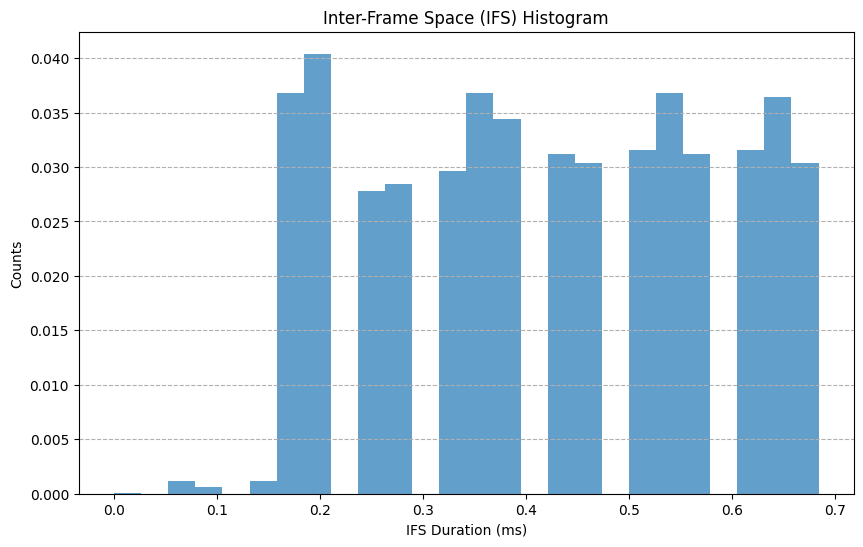

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ifs_histogram(data_row):
    """
    Plots the Inter-Frame Space (IFS) histogram from a single row of the dataset.

    Args:
        data_row (list or numpy.ndarray): A list or array representing a single row
                                          in the format (x1, ..., x26, y1, ..., y26, s, r, l).
    """

    # Get IFS values and the corresponding counts
    x_values = np.array(data_row[:26])
    y_counts = np.array(data_row[26:52])

    # Calculate the bin edges based on x_values
    bin_edges = [0] + list(x_values)

    # Create the histogram plot
    plt.figure(figsize=(10, 6))
    plt.bar(bin_edges[:-1], y_counts, width=np.diff(bin_edges)[0], align='edge', alpha=0.7)

    # Add labels and title
    plt.xlabel("IFS Duration (ms)")
    plt.ylabel("Counts")
    plt.title("Inter-Frame Space (IFS) Histogram")
    plt.grid(axis='y', linestyle='--')

    # Show the plot
    plt.show()

# Example usage

# -> Read the data file
file_name = mypath + '/train_data.csv'
train_data_df = pd.read_csv(file_name, header=None)
print(train_data_df.head())

# -> Get a sample from the dataset and plot it
row_index = 1
sample_data = train_data_df.iloc[row_index].values
plot_ifs_histogram(sample_data)

## EXERCISES

**Imports**

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

### Exercise 1:
Define an approach for training and validating the model you are going to train with the proposed data. Then, perform the split accordingly.

*We define an 80% train and 20% validation split*

In [18]:
# (response to exercise 1)
X = np.array(train_data_df.iloc[:, :-1])
y = np.array(train_data_df.iloc[:, -1])
values_train, values_val, labels_train, labels_val = train_test_split(X, y, train_size=0.8, shuffle=True) #We shuffle the data to ensure the model sees both 0 and 1 examples in all sets.

#scaler = StandardScaler()
#values_train_scaled = scaler.fit_transform(values_train)
#values_val_scaled = scaler.transform(values_val)

### Exercise 2:

Define your ML model, so that it can be called for training and test. Examples of approaches that you could use (but not limited to):

*   Logistic Regression
*   K-Nearest Neighbors (KNN)
*   Decision Trees or Random Forests
*   Convolutional Neural Network (CNN)

In [19]:
# (response to exercise 2)
model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

### Exercise 3:

Define the hyperparameters that you will use to train the model.

In [20]:
# (response to exercise 3)
lr = 0.001
num_epochs = 500
activation = 'relu'
hidden_layer_sizes = (128,64)

### Exercise 4:
Train the model and show the procedure (e.g., evolution of the training/validation loss).

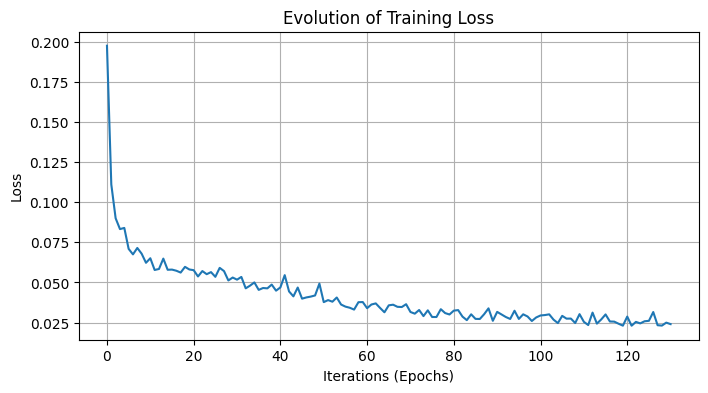

In [21]:
# (response to exercise 4)
lr = 0.005
mlp = MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes,
    max_iter=num_epochs,
    alpha=0.0001,
    solver='adam',
    verbose=False,
    random_state=42,
    learning_rate_init=lr,
    learning_rate='constant'
)

# 2. Train
mlp.fit(values_train, labels_train)

# 3. Plot the Loss Curve (Evolution of training)
plt.figure(figsize=(8,4))
plt.plot(mlp.loss_curve_)
plt.title("Evolution of Training Loss")
plt.xlabel("Iterations (Epochs)")

plt.ylabel("Loss")
plt.grid(True)
plt.show()

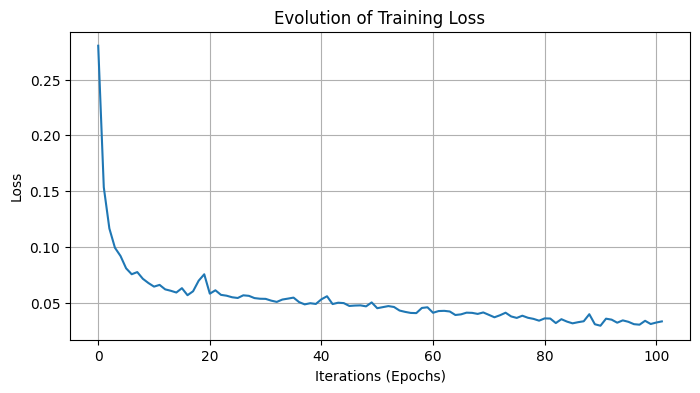

In [22]:
lr = 0.001
mlp = MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes,
    max_iter=num_epochs,
    alpha=0.0001,
    solver='adam',
    verbose=False,
    random_state=42,
    learning_rate_init=lr,
    learning_rate='constant'
)

# 2. Train
mlp.fit(values_train, labels_train)

# 3. Plot the Loss Curve (Evolution of training)
plt.figure(figsize=(8,4))
plt.plot(mlp.loss_curve_)
plt.title("Evolution of Training Loss")
plt.xlabel("Iterations (Epochs)")

plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Exercise 5:

Select and define the most appropriate evaluation metric(s). Discuss the appropriateness of your evaluation metrics for the binary classification problem we are considering.

Validation Accuracy: 98.30%

Classification Report:
                   precision    recall  f1-score   support

Not Saturated (0)       0.97      0.99      0.98      1976
    Saturated (1)       0.99      0.97      0.98      2024

         accuracy                           0.98      4000
        macro avg       0.98      0.98      0.98      4000
     weighted avg       0.98      0.98      0.98      4000



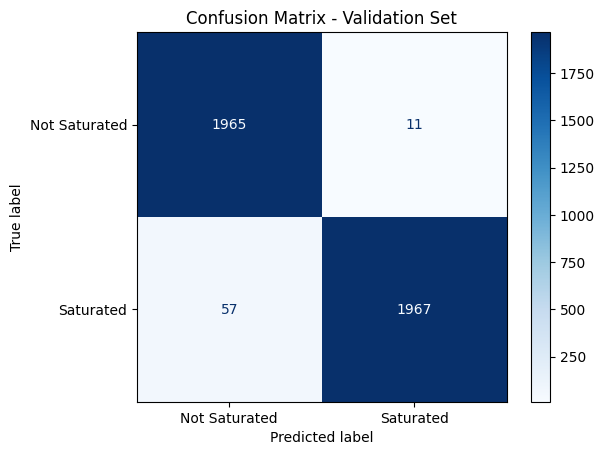

In [26]:
# 1. Get predictions on the validation set
predictions = mlp.predict(values_val)

# 2. Accuracy
print(f"Validation Accuracy: {accuracy_score(labels_val, predictions):.2%}")

# 3. Full classification report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(labels_val, predictions, target_names=['Not Saturated (0)', 'Saturated (1)']))

# 4. Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(labels_val, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Saturated', 'Saturated'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Validation Set')
plt.show()

**Explication:** So, the Validation Accuracy is 98.30% which means that the model correctly classified 98.3% of the 4000 validation samples.

Out of 4000 samples it only made 68 mistakes total: 11 false alarms (said "congested" when it wasn't) and 57 missed detections (said "fine" when it was actually congested). Missing real congestion is worse than a false alarm in practice, but 57 out of 2024 saturated cases is still very good.
Both classes have F1 = 0.98, meaning the model performs equally well detecting congestion and non-congestion, it's not biased toward one class.

### Exercise 6:

Evaluate your trained model on the test set, using the evaluation metrics that you have proposed. Remember that the test data should have not been seen by the model, so that we can properly estimate of its generalization capabilities.

Test Accuracy: 95.40%

Classification Report (Test Set):
                   precision    recall  f1-score   support

Not Saturated (0)       1.00      0.90      0.95       240
    Saturated (1)       0.92      1.00      0.96       260

         accuracy                           0.95       500
        macro avg       0.96      0.95      0.95       500
     weighted avg       0.96      0.95      0.95       500



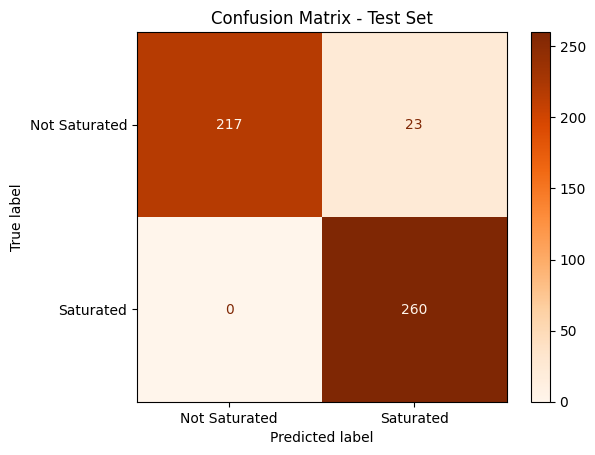

In [24]:
# 1. we load the test data
test_file = mypath + '/test_data.csv'
test_data_df = pd.read_csv(test_file, header=None)

# 2. Split features and labels
X_test = np.array(test_data_df.iloc[:, :-1])
y_test = np.array(test_data_df.iloc[:, -1])

# 3. Predict on the test set (model has never seen this data)
test_predictions = mlp.predict(X_test)

# 4. Evaluate with the same metrics as Exercise 5
print(f"Test Accuracy: {accuracy_score(y_test, test_predictions):.2%}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, test_predictions, target_names=['Not Saturated (0)', 'Saturated (1)']))

# 5. Confusion Matrix on test set
cm_test = confusion_matrix(y_test, test_predictions)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Not Saturated', 'Saturated'])
disp_test.plot(cmap='Oranges')
plt.title('Confusion Matrix - Test Set')
plt.show()

**Explanation:** The model got 95.4% accuracy on the test set, about 3% less than validation.

This small drop is completely normal and expected as the test set is data the model has never seen before, so it's the most honest measure of real performance.
The most remarkable result here is that the model made 0 missed congestions, it caught every single saturated case. The trade-off is 23 false alarms (flagging congestion when the network was fine), but in a real Wi-Fi network that's the safer error to make: better to trigger congestion control unnecessarily than to ignore real congestion.

Overall, the model generalizes well. Validation and test accuracy are close to each other, which means the model actually learned the pattern and didn't just memorize the training data.